# Inverse-Wishart Distribution

`InverseWishart(df, scale)` is a distribution over symmetric, positive-definite matrices, obtained by inverting a `Wishart` draw. It is the matrix generalization of the inverse-gamma distribution and the standard conjugate prior for the *covariance* matrix of a multivariate normal.

In [7]:
from symbulate import *

## Draw a value

Each draw is a `p x p` symmetric positive-definite matrix, shown as a vector of its rows.

In [8]:
InverseWishart(df=5, scale=[[1, 0], [0, 1]]).draw()

((0.15365026880844426, 0.039343818839838805), (0.039343818839838805, 0.19636144836172062))

## Simulate

Every simulated value is a 2x2 matrix.

In [9]:
InverseWishart(df=5, scale=[[1, 0], [0, 1]]).sim(1000)

0,"((0.6225386589478668, -0.678838087468692), (-0.678838087468692, 0.9318508978831135))"
1,"((0.4233225878716818, 0.24230398426497055), (0.24230398426497055, 0.3106531602629479))"
2,"((0.1187364343911759, 0.03014070175351378), (0.03014070175351378, 0.10161509933381707))"
3,"((0.48610187160177576, -0.05562125726090018), (-0.05562125726090018, 0.1086122530960694))"
4,"((0.11981061374590171, 0.021768970912774032), (0.021768970912774032, 0.2443874358982167))"
5,"((0.7177207632175698, 0.22962509565380165), (0.22962509565380165, 0.22077898260535794))"
6,"((0.09274329809494794, -0.026973437138626332), (-0.026973437138626332, 0.162163145264569))"
7,"((0.5979998243194581, 0.27720561292333545), (0.27720561292333545, 0.6673576183455218))"
8,"((0.2219725608206539, -0.22863774138614007), (-0.22863774138614007, 0.6010378159622262))"
...,...
999,"((0.2666928125044367, 0.05392762481310278), (0.05392762481310278, 0.4828392398280568))"


## Evaluate the pdf at a matrix

The density is defined over symmetric positive-definite matrices, so the point passed to `pdf` is itself a matrix.

In [10]:
InverseWishart(df=5, scale=[[1, 0], [0, 1]]).pdf([[1, 0], [0, 1]])

np.float64(0.004879152627026595)

## Relationship: inverting a draw gives a Wishart

If `X ~ InverseWishart(df, scale)`, then the matrix inverse of `X` is `Wishart(df, inv(scale))`. With an identity scale (whose inverse is also the identity), the top-left entry of the inverted draw is a chi-square with `df` degrees of freedom.

Simulating... [██████████████████████████████] 10000/10000 (100%)


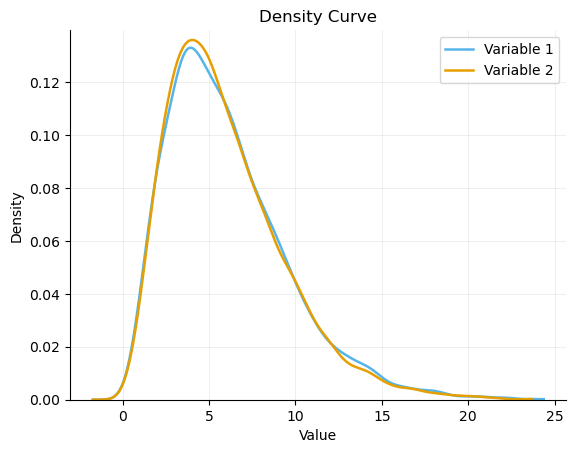

In [11]:
import numpy as np
X = RV(InverseWishart(df=6, scale=[[1, 0], [0, 1]]))
X.apply(lambda m: np.linalg.inv(np.array([list(r) for r in m]))[0, 0]).sim(10000).plot(type="density")
RV(ChiSquare(df=6)).sim(10000).plot(type="density")

## Relationship: the 1x1 inverse-Wishart is an inverse-gamma

In one dimension the inverse-Wishart reduces to an inverse-gamma: `InverseWishart(df, [[s]])` equals `InverseGamma(shape=df/2, scale=s/2)`. Here `df=6`, `s=2`.

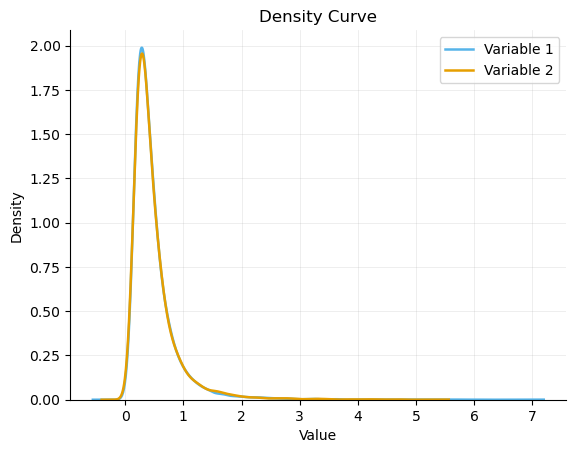

In [12]:
Y = RV(InverseWishart(df=6, scale=[[2]]))
Y.apply(lambda m: m[0][0]).sim(10000).plot(type="density")
RV(InverseGamma(shape=6 / 2, scale=2 / 2)).sim(10000).plot(type="density")